# Lab 3: Numerical solution of a constrained problem

**Report by Ugo Roccamatisi.**


<h1><a id='toc'></a>Contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ul>
        <li><a href="#I">I. Theoretical study</a></li>
        <ul>
        <li><a href="#I1">I.1. Existence and uniqueness of the minimizer</a></li>
        <li><a href="#I2">I.2. KKT conditions and explicit computation of the minimizer</a></li>
        </ul>    
        <li><a href="#II">II. Numerical optimization with the interior-point method</a>
        <li><a href="#III">III. Numerical optimization with Uzawa's algorithm</a></li>
        </li>
    </ul>
</div>
<br>
<hr>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## I. Theoretical study
<a id='I'></a>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

We want to minimize:
$$
J(x) := 3x_1^2 + 3x_2^2 -2x_1x_2 - 3x_1- 7x_2 + 9.
$$
subject to $x\in C$, where 
$$
C:=\{x\in\mathbb{R}^2: f_1(x)\le 0,\, f_2(x)\le 0\}
$$with 
$$
f_1(x_1,x_2):=x_1^2+x_2^2-1,\qquad\quad f_2(x_1,x_2):=2x_1-1.
$$

### I.1 Existence and uniqueness of a minimizer
<a id='I1'></a>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

$C$ contains $(0,0)$, so it is non-empty. The functions $f_1$, $f_2$ are smooth and convex, so $C$ is a non-empty closed convex set. 
Moreover $C\subset \{x\in\mathbb{R}^2:\|x\|\le 1\}$, so $C$ is compact.

$J$ is a degree-2 polynomial, hence smooth, and $J$ has at least one minimum point on $C$. We compute 
$$
\nabla J(x)=\binom{6x_1-2x_2-3}{6x_2-2x_1-7},
$$
and 
$$
D^2J(x)=\left(\begin{array}{cc}6&-2\\-2&6\end{array}\right) = : A.
$$
The eigenvalues of $A$ are the roots of $(X-6)^2-4=X^2-12 X+32$, i.e.
$$
X_-=6-\sqrt4=4,\qquad X_+=6+\sqrt4=8.
$$
Hence $A$ is positive definite and $J$ is $4$-convex, therefore strictly convex, and the minimizer of $J$ on $C$ is unique. We denote it $x^*$.

### I.2 KKT conditions and computation of the minimizer
<a id='I2'></a>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

From the previous discussion, the problem has the form studied in the lecture 
$$
\tag{P} \min_{f_1\le0,\,f_2\le0} J,
$$
with $J$, $f_1$, $f_2$ convex and $C^1$, and $J$ even $\alpha$-convex (with $\alpha=2$). 

Moreover, at $(0,0)$ we have $f_1<0$ and $f_2<0$, so Slater's condition holds. The minimizer $x^*$ is therefore the unique point satisfying the KKT conditions, i.e.:
$$
f_1(x^*),f_2(x^*)\le 0 \text{ and there exist }\lambda_1^*,\lambda_2^*\ge0\text{ such that}\begin{cases} \lambda_1^*f_1(x^*)=\lambda_2^*f_2(x^*)=0,\\\nabla J(x^*)+\lambda_1^*\nabla f_1(x^*)+\lambda_2^*\nabla f_2(x^*)=0.\end{cases}
$$

We start by plotting $C$ and the level lines of $J$.

Rather than enumerating all four cases
$$
\{f_1(x^*),f_2(x^*)<0\},\ \{f_1(x^*)<0,f_2(x^*)=0\},\ \{f_1(x^*)=0,f_2(x^*)<0\},\ \{f_1(x^*)=f_2(x^*)=0\},
$$
we try to determine graphically which one holds. 

To do so, we plot the boundary of $C$ and a few level lines of $J$. 

In [2]:
def level_lines(f, xmin, xmax, ymin, ymax, levels, N=500):
    x = np.linspace(xmin, xmax, N)
    y = np.linspace(ymin, ymax, N)
    z = f(*np.meshgrid(x, y))
    level_l = plt.contour(x, y, z, levels=levels)
    plt.clabel(level_l, levels, fmt='%.1f') 

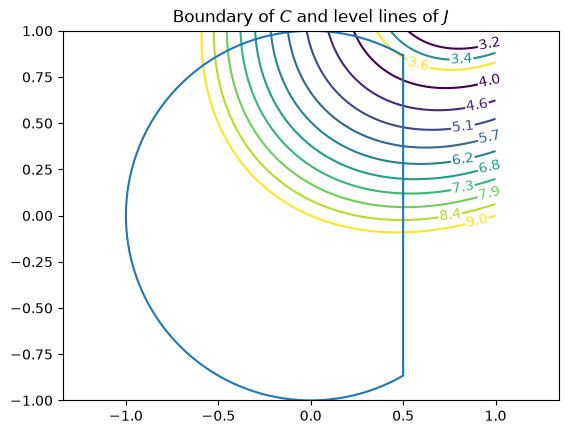

In [3]:
Jxy = lambda x,y: 3*x**2 + 3*y**2 - 2*x*y - 3*x - 7*y + 9

levels=np.linspace(4,9,10)
level_lines(Jxy, -1, 1, -1, 1, levels)
levels=np.linspace(3.2,3.6,3)
level_lines(Jxy, -1, 1, -1, 1, levels)

N=100
theta=np.zeros(N+2)
theta[:-1]=np.linspace(np.pi/3,5*np.pi/3,N+1)
theta[N+1]=theta[0]
plt.plot(np.cos(theta),np.sin(theta))
plt.axis("equal")
plt.title(r"Boundary of $C$ and level lines of $J$")
plt.show()

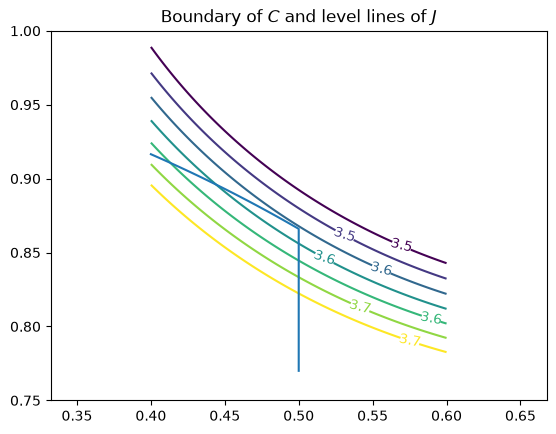

In [4]:
# Zoom around (cos(π/3), sin(π/3)) = (1/2,√3/2)
levels=np.linspace(3.5,3.7,7)
level_lines(Jxy, .4, .6, .75, 1, levels)

N=40
theta=np.linspace(np.pi/3,np.arccos(.4),N+1)
xs,ys=np.zeros(N+2), np.zeros(N+2)
xs[0], ys[0] = .5, .77
xs[1:], ys[1:] = np.cos(theta), np.sin(theta)
plt.plot(xs,ys)
plt.axis("equal")
plt.title(r"Boundary of $C$ and level lines of $J$")
plt.show()

Graphically, the minimizer of $J$ on $C$ seems to be the point
$$
\bar x:=(\cos \pi/3,\sin\pi/3)=(1/2,\sqrt3/2).
$$

**Question 1.**
Show that $\bar x$ is indeed the solution of the optimization problem.

**Solution 1.**
Both constraints $f_1$ and $f_2$ are active at $\bar x$, i.e. $f_1(\bar x)=f_2(\bar x)=0$. We therefore check that there exist $\lambda_1,\lambda_2\ge0$ such that
$$
\tag{*}\nabla J(\bar x)+\lambda_1\nabla f_1(\bar x)+\lambda_2\nabla f_2(\bar x)=0.
$$
We compute 
$$
\nabla J(\bar x)=\binom{6\bar x_1-2\bar x_2-3}{6\bar x_2-2\bar x_1-7}=\binom{-\sqrt3}{3\sqrt3-8},
$$
$$
\nabla f_1(\bar x)=2\binom{\bar x_1}{\bar x_2}=\binom1{\sqrt3},\qquad \nabla f_2(\bar x)=\binom20.
$$

System ($*$) is therefore equivalent to the linear system 
$$
\binom{-\sqrt3}{3\sqrt3-8}+\left(\begin{array}{cc}1&2\\\sqrt3&0\end{array}\right)\binom{\lambda_1}{\lambda_2}=\binom00\quad\iff\quad\left(\begin{array}{cc}1&2\\\sqrt3&0\end{array}\right)\binom{\lambda_1}{\lambda_2}=\binom{\sqrt3}{8-3\sqrt3}.
$$

We obtain 
$$
\lambda_1=8\sqrt3/3-3,\qquad\lambda_2=(3/2)-5\sqrt3/6,
$$
and since $\lambda_1,\lambda_2\ge0$ (in fact $\lambda_1,\lambda_2>0$), $(\bar x,\lambda_1,\lambda_2)$ satisfies the KKT conditions. Hence 
$$
x^*=\bar x=(1/2,\sqrt3/2).
$$
(Moreover, $(\bar x,\lambda_1,\lambda_2)$ is the unique saddle point of the Lagrangian of problem (P).)

## II. Interior-point method <a id='II'></a>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

**Question 2.**
Implement the interior-point method to minimize $J$ on $C$. Illustrate the results with plots showing the convergence of $x^k$ and $J(x^k)$.

**Hint 2.1.** The Python functions below build the functions 
$$
J(x),\qquad f(x)=[f_1(x),f_2(x)].
$$
For $t>0$, we can build the functions

$$
J_t(x)=J(x)-t[\log(-f_1(x)) + \log(-f_2(x))]\qquad\text{and}\qquad \nabla J_t(x). 
$$

To do so, use the Python commands:

$$
\textrm{Jt}=\textrm{buildJt}(t)\qquad\text{and}\qquad \textrm{GradJt}=\textrm{buildGradJt}(t).
$$

In [5]:
f = lambda x: np.array([x[0]**2 + x[1]**2 - 1,2*x[0] - 1])

J = lambda x: 3*x[0]**2 + 3*x[1]**2 - 2*x[0]*x[1] - 3*x[0] - 7*x[1] + 9

buildJt= lambda t: lambda x: (3*x[0]**2 + 3*x[1]**2 - 2*x[0]*x[1] - 3*x[0] - 7*x[1] 
                             + 9 - t*(np.log(1 - x[0]**2 - x[1]**2)
                                     + np.log(1 - 2*x[0])))
def buildGraJt(t):
    dJt =lambda x: np.array([6*x[0] - 2*x[1] - 3 
                    + 2*t*(x[0]/(1 - x[0]**2 - x[1]**2) + 1/(1 - 2*x[0])),
                               6*x[1] - 2*x[0] - 7 
                    + 2*t*x[1]/(1 - x[0]**2 - x[1]**2)])
    return dJt

**Hint 2.2.** First minimize $J_t$ with $t=1$, starting from $x^0=(0,0)$. Use gradient descent with a backtracking line search based on the Armijo criterion to choose the step (with parameters $c=1/2$ and $\beta=3/4$). 

**Hint 2.3.** Then take $t=1/2$ and minimize $J_t$ starting from the last iterate obtained with $t=1$. Continue with $t=1/4$, ..., $t=1/2^8$.

**Result.** The barrier method ends with a value gap of about 9.10 × 10⁻⁴. The iterates must stay strictly inside the domain of the logarithms, and the value reached depends on the last barrier parameter.


**Solution 2.**

In [6]:
# Parameters
I=12

Niter = 5000
epsilon = 1e-8

alpha = .1
c, beta = .5, .75 
Niter_ls = 8


# Initialization
flag =0
t=1
Jt, dJt = buildJt(t), buildGraJt(t)
x=np.zeros([2])
X, F, E, Et, Ng = [], [], [], [], [] 

In [7]:
# Minimization of Jt
for i in range(I):
    Jtx, g =  Jt(x), dJt(x)
    ng = np.linalg.norm(g)
    X.append([x]); F.append([f(x)])
    E.append([J(x)]); Et.append([Jtx]); Ng.append([ng])
    ng0=ng
    niter=0
    while ng>epsilon*ng0 and niter<Niter:
        coef = c*ng**2
        step =alpha
        newx = x - step*g 
        newJtx = Jt(newx)
        niter_ls = 0
        for j in range(Niter_ls):
            if newJtx < Jtx - coef*step:
                break
            else:
                step *= beta
                newx = x - step*g 
                newJtx = Jt(newx)
        if niter_ls == Niter_ls: 
            print(f"i={i}, niter={niter}, step={step}, ng={ng}")
            flag = 1
            break
        x, Jtx = newx, newJtx
        g = dJt(x)
        ng = np.linalg.norm(g)
        niter += 1
        X[i].append(x); F[i].append(f(x)) 
        E[i].append(J(x)); Et[i].append(Jt(x))
    if flag: break
    t /= 2
    alpha /= 2
    Jt, dJt = buildJt(t), buildGraJt(t)

In [8]:
xstar=np.array([1/2,np.sqrt(3)/2])
E0=J(xstar)
Ecart_final=J(x)-E0
print(f"Final gap = {Ecart_final:1.4e}")

Final gap = 9.1019e-04


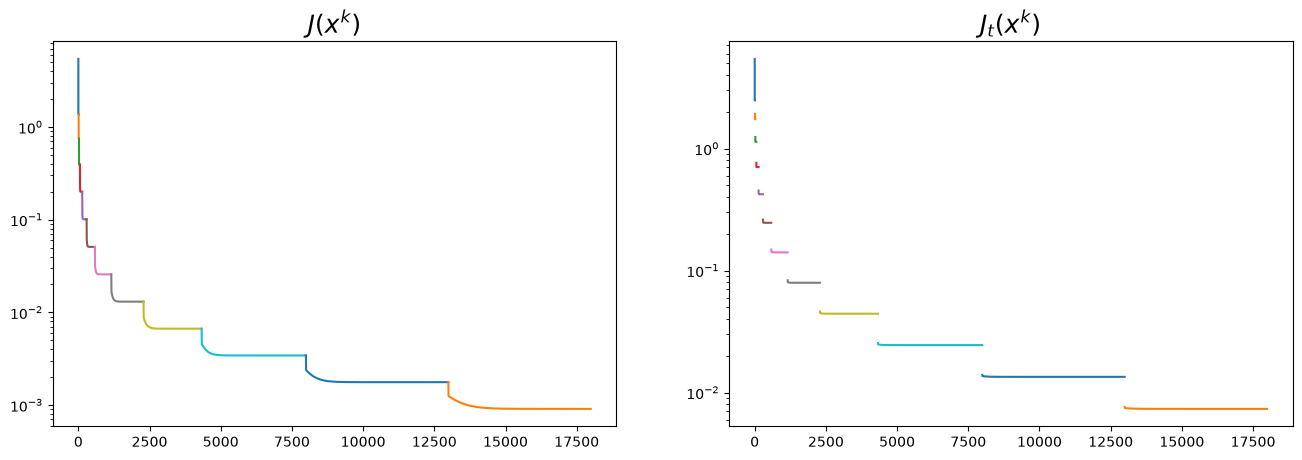

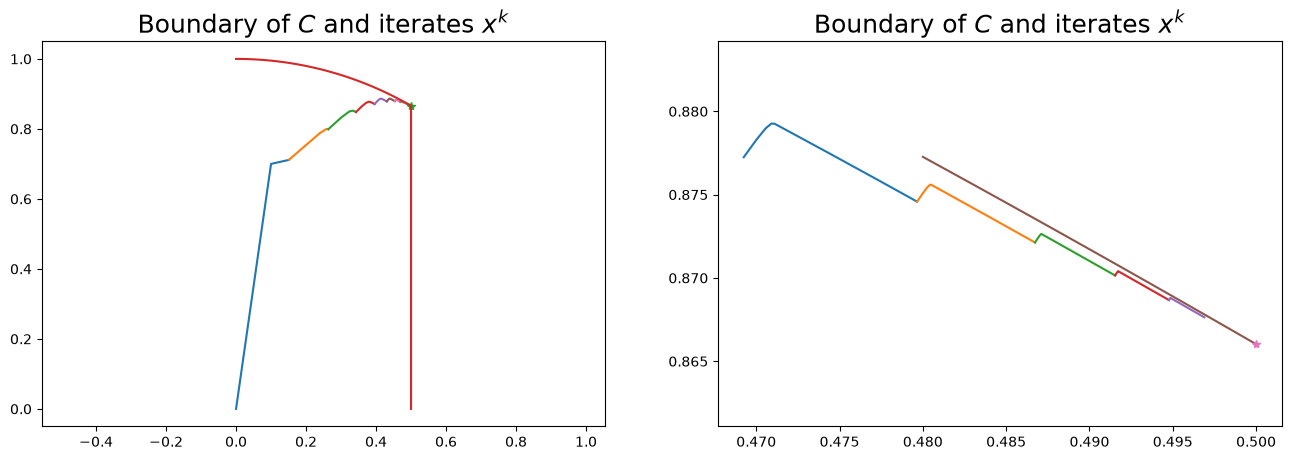

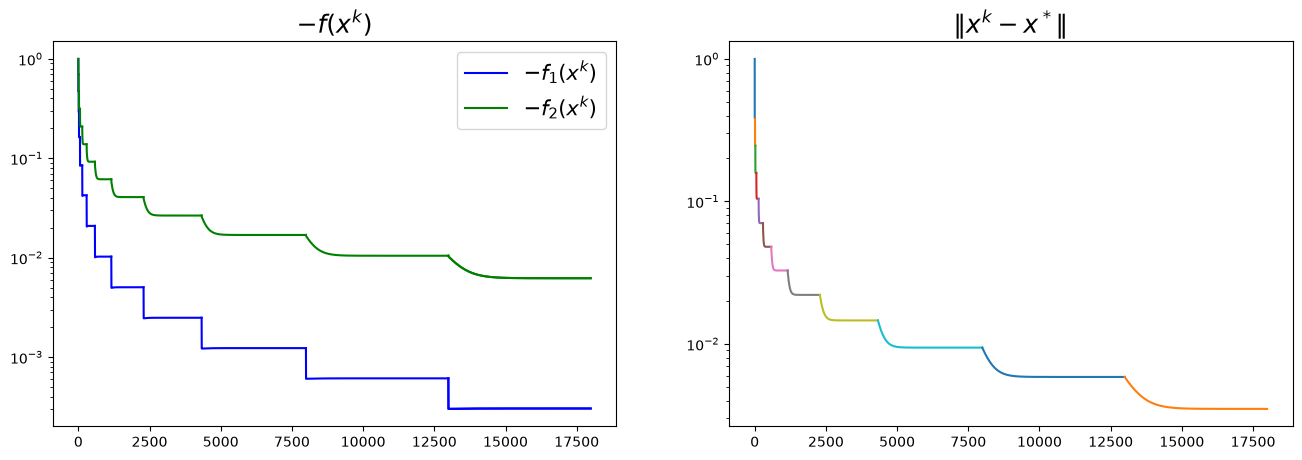

In [9]:
plt.figure(figsize=(16,5))
plt.subplot(121)
n_=0
nn=[0]
for i in range(I):
    e = np.array(E[i])
    n=len(e)+n_
    plt.semilogy(range(n_,n), e-E0)
    n_ = n
    nn.append(n)
plt.title(r"$J(x^k)$",fontsize=18)

plt.subplot(122)
for i in range(I):
    e = np.array(Et[i])
    plt.semilogy(range(nn[i],nn[i+1]),e-E0)
plt.title(r"$J_t(x^k)$",fontsize=18)
plt.show()

plt.figure(figsize=(16,5))
plt.subplot(121)
for i in range(I):
    xx=np.array(X[i])
    plt.plot(xx[:,0],xx[:,1])
plt.plot([xstar[0]],[xstar[1]],'*')

N=40
theta=np.linspace(np.pi/3,np.pi/2,N+1)
xs,ys=np.zeros(N+2), np.zeros(N+2)
xs[0], ys[0] = .5, 0.
xs[1:], ys[1:] = np.cos(theta), np.sin(theta)
plt.plot(xs,ys)
plt.axis("equal")
plt.title(r"Boundary of $C$ and iterates $x^k$",fontsize=18)


plt.subplot(122)
i0=7
for i in range(I-i0):
    xx=np.array(X[i+i0])
    plt.plot(xx[:,0],xx[:,1])
plt.plot([1/2],[np.sqrt(3)/2],'r')

theta=np.linspace(np.pi/3,np.arccos(.48),N+1)
plt.plot(np.cos(theta), np.sin(theta))
plt.plot(xstar[0],xstar[1],'*')
plt.axis("equal")
plt.title(r"Boundary of $C$ and iterates $x^k$",fontsize=18)

plt.show()

## Constraints and distance to x*

plt.figure(figsize=(16,5))
plt.subplot(121)
for i in range(I):
    ff=np.array(F[i])
    plt.plot(range(nn[i],nn[i+1]),-ff[:,0],'b')
    plt.plot(range(nn[i],nn[i+1]),-ff[:,1],'g')
i=I-1
plt.semilogy(range(nn[i],nn[i+1]),-ff[:,0],'b',label=r"$-f_1(x^k)$")
plt.semilogy(range(nn[i],nn[i+1]),-ff[:,1],'g',label=r"$-f_2(x^k)$")
#plt.plot([0,nn[-1]-1], [0,0],'-r',label="0")    
plt.legend(fontsize=15)
plt.title(r"$-f(x^k)$",fontsize=18)

plt.subplot(122)
for i in range(I):
    err_x=np.linalg.norm(np.array(X[i])-xstar,axis=1)
    plt.semilogy(range(nn[i],nn[i+1]),err_x)
plt.title(r"$\|x^k-x^*\|$",fontsize=18)
plt.show()


<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

## III. Uzawa's algorithm <a id='III'></a>

<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

For $x\in\mathbb{R}^2$ and $\lambda=(\lambda_1,\lambda_2)\in(\mathbb{R_+})^2$, let
$$
\mathcal{L}(x,\lambda):=J(x)+\lambda_1f_1(x)+\lambda_2f_2(x).
$$
This is the Lagrangian of problem (P). 

For $\lambda\in(\mathbb{R_+})^2$, let
$$
H(\lambda) =\min_{x\in\mathbb{R}^2} \mathcal{L}(x,\lambda)
$$
The function $x\mapsto \mathcal{L}(x,\lambda)$ is $C^1$ and 2-convex, so its minimizer is well defined and unique. We denote it $x^\lambda$. It is also the unique solution of 
$$
\tag{**}
0=\nabla_x\mathcal{L}(x,\lambda)=\nabla J(x)+\lambda_1\nabla f_1(x)+\lambda_2\nabla f_2(x).
$$

Here ($**$) can be solved explicitly. We compute 
$$
\nabla_x\mathcal{L}(x,\lambda)=\binom{(6+2\lambda_1)x_1-2x_2+2\lambda_2-3}{(6+2\lambda_1)x_2-2x_1-7},
$$
hence 
$$
(**)\ \iff\ \left(\begin{array}{cc}6+2\lambda_1&-2\\-2&6+2\lambda_1\end{array}\right)\binom{x_1}{x_2}=\binom{3-2\lambda_2}7\ \iff\ Sx=b,
$$
with 
$$
S=\left(\begin{array}{cc}3+\lambda_1&-1\\-1&3+\lambda_1\end{array}\right),\qquad b=\binom{3/2-\lambda_2}{7/2}.
$$

We invert $S$ with the formula $S^{-1}=(\det S)^{-1}(\mathrm{Com}\,S)^T$. We have $\det S=8+6\lambda_1+\lambda_1^2$ and
$$
\text{Com}\,S=\left(\begin{array}{cc}3+\lambda_1&1\\1&3+\lambda_1\end{array}\right).
$$
Therefore 
$$
x^\lambda_1=\dfrac{8+(3/2)\lambda_1-3\lambda_2-\lambda_1\lambda_2}{8+6\lambda_1+\lambda_1^2},\qquad x^\lambda_2=\dfrac{12+ (7/2)\lambda_1-\lambda_2}{8+6\lambda_1+\lambda_1^2}
$$

We deduce that for $\lambda\in(\mathbb{R}_+)^2$,
$$
H(\lambda)=J(x^\lambda)+\lambda_1f_1(x^\lambda)+\lambda_2f_2(x^\lambda)=\mathcal{L}(x^\lambda,\lambda).
$$
Hence, for $i=1,2$,
$$
\dfrac{\partial H(\lambda)}{\partial \lambda_i}=D_x\mathcal{L}(D x^\lambda)\dfrac{d x^\lambda}{d\lambda_i} + f_i(x^\lambda)=f_i(x^\lambda).
$$
Indeed, $D_x\mathcal{L}(D x^\lambda)=0$ by optimality of $x^\lambda$.<br>
Therefore 
$$
\dfrac{\partial H(\lambda)}{\partial \lambda_1}=(x^\lambda_1)^2+(x^\lambda_2)^2-1.
$$
and
$$
\dfrac{\partial H(\lambda)}{\partial \lambda_2}=2x^\lambda_1-1.
$$

**Question 3.**
Implement Uzawa's algorithm to minimize $J$ on $C$.

The algorithm is a projected gradient method to maximize $H$. 

One iteration consists of:<br>
$~\qquad$ Compute $x^{\lambda^k}$<br>
$~\qquad$ $d^k\leftarrow \nabla H({\lambda^k})=f(x^{\lambda^k})$<br>
$~\qquad$ $\mu^k\leftarrow \lambda^k + \alpha d^k$ $\quad$ (gradient step)<br>
$~\qquad$ $\lambda^{k+1} \leftarrow \Pi_{\mathbb{R}_+^2}(\mu^k)$  (projection step).

**Hint 3.1.** The Python functions below build the functions 

$$
J(x),\qquad\qquad f(x)=[f_1(x),f_2(x)],
$$

as well as a function xl(l) that computes $x^\lambda$ and a function proj(l) that projects onto $\mathbb{R}_+^2$. 

In [10]:
J = lambda x: 3*x[0]**2 + 3*x[1]**2 - 2*x[0]*x[1] - 3*x[0] - 7*x[1] + 9

f = lambda x: np.array([x[0]**2 + x[1]**2 - 1,2*x[0] - 1])

def xl(l):
    denom = (l[0] + 3)**2 - 1
    x1 = (8 + 1.5*l[0] - 3*l[1]- l[0]*l[1])/denom
    x2 = (12 + 3.5*l[0] - l[1])/denom
    return np.array([x1, x2])

proj = lambda l : np.where(l<0,0,l)    

**Solution 3.**

**Result.** After 500 iterations, Uzawa recovers $x^*=(\tfrac12,\tfrac{\sqrt3}{2})$ to machine precision. Both constraints are active at the limit and the multipliers are about (1.6188, 0.05662).


In [11]:
# Parameters and initialization
alpha = 1
Niter = 500

l=np.array([1,1])
x = xl(l)
fx =f(x)
X, L, F, E = [x], [l], [fx], [J(x)]

In [12]:
# Projected gradient algorithm
for niter in range(Niter):
    l = l + alpha*fx
    l = np.where(l<0,0,l)
    x = xl(l)
    fx =f(x)
    X.append(x); L.append(l); F.append(fx); E.append(J(x))

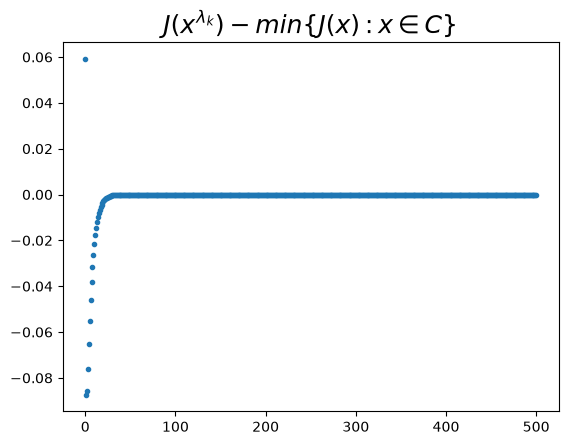

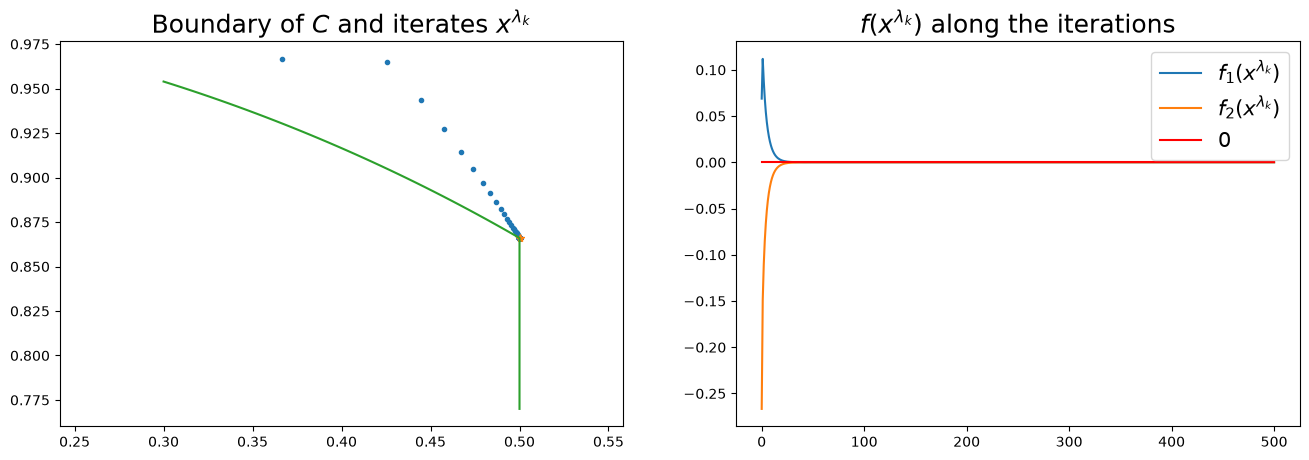

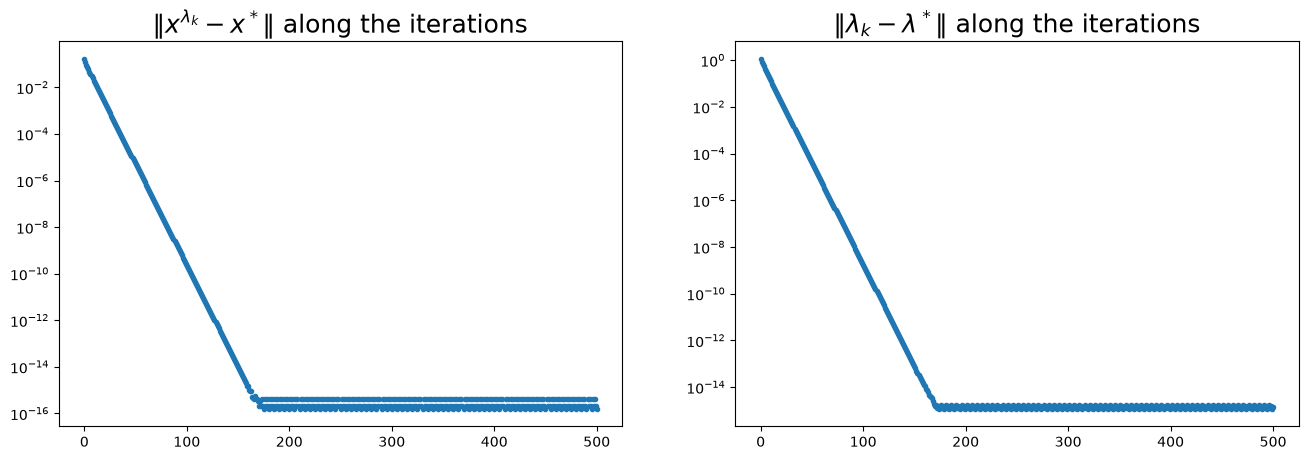

In [13]:
xstar=np.array([1/2,np.sqrt(3)/2])
E0=J(xstar)

plt.plot(E-E0,'.')
plt.title(r"$J(x^{\lambda_k})-min \{J(x):x\in C\}$",fontsize=18)
plt.show()

plt.figure(figsize=(16,5))
plt.subplot(121)
X=np.array(X)
plt.plot(X[:,0],X[:,1],'.')
plt.plot([xstar[0]],[xstar[1]],'*')

N=40
theta=np.linspace(np.pi/3,np.arccos(.3),N+1)
xs,ys=np.zeros(N+2), np.zeros(N+2)
xs[0], ys[0] = .5, .77
xs[1:], ys[1:] = np.cos(theta), np.sin(theta)
plt.plot(xs,ys)
plt.axis("equal")
plt.title(r"Boundary of $C$ and iterates $x^{\lambda_k}$",fontsize=18)

plt.subplot(122)
F=np.array(F)
plt.plot(F[:,0],label=r"$f_1(x^{\lambda_k})$")
plt.plot(F[:,1],label=r"$f_2(x^{\lambda_k})$")
plt.plot([0,len(F[:,0])-1], [0,0],'r', label="0")
plt.legend(fontsize=15)
plt.title(r"$f(x^{\lambda_k})$ along the iterations",fontsize=18)
plt.show()


plt.figure(figsize=(16,5))
plt.subplot(121)
xstar=np.array([1/2,np.sqrt(3)/2])
err_x=np.linalg.norm(X-xstar,axis=1)
plt.semilogy(err_x,'.')
plt.title(r"$\|x^{\lambda_k}-x^*\|$ along the iterations",fontsize=18)

plt.subplot(122)
lstar=np.array([8/np.sqrt(3) - 3, 1.5 - 2.5/np.sqrt(3)])
err_l=np.linalg.norm(L-lstar,axis=1)
plt.semilogy(err_l,'.')
plt.title(r"$\|\lambda_k-\lambda^*\|$ along the iterations",fontsize=18)
plt.show()

<a id='bot'></a>
<a href="#toc">top</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I">I.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I1">I.1</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#I2">I.2</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#II">II.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#III">III.</a>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<a href="#bot">bot.</a>

In [14]:
# Summary after Uzawa: feasibility, multipliers and value gap.
print("x final =",np.round(X[-1],8),"; x* =",xstar)
print("Final multipliers =",np.round(L[-1],8))
print("Constraints f(x) =",np.round(f(X[-1]),8))
print("Gap J(x)-J(x*) =",J(X[-1])-J(xstar))


x final = [0.5       0.8660254] ; x* = [0.5       0.8660254]
Final multipliers = [1.61880215 0.05662433]
Constraints f(x) = [-0. -0.]
Gap J(x)-J(x*) = 8.881784197001252e-16
